# BEE 4750 Homework 5: Mixed Integer and Stochastic Programming

**Name**: Sadiqah Quadery

**ID**: sq227

> **Due Date**
>
> Thursday, 12/04/24, 9:00pm

## Overview

### Instructions

-   In Problem 1, you will use mixed integer programming to solve a
    waste load allocation problem.
-   In Problem 2, you will formulate a stochastic optimization problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4750/hw5-sadiqahquadery`
   Installed Measures ─────────── v0.3.3
   Installed GR_jll ───────────── v0.73.18+0
   Installed OpenBLAS32_jll ───── v0.3.29+0
   Installed PlotUtils ────────── v1.4.4
   Installed OpenSSL ──────────── v1.6.0
   Installed StaticArrays ─────── v1.9.15
   Installed MutableArithmetics ─ v1.6.7
   Installed Pango_jll ────────── v1.57.0+0
   Installed FFMPEG ───────────── v0.4.5
   Installed StaticArraysCore ─── v1.4.4
   Installed HiGHS_jll ────────── v1.12.0+0
   Installed JSON ─────────────── v1.3.0
   Installed Graphs ───────────── v1.13.1
   Installed StatsBase ────────── v0.34.8
   Installed METIS_jll ────────── v5.1.3+0
   Installed DataStructures ───── v0.19.3
   Installed ChainRulesCore ───── v1.26.0
   Installed Adapt ────────────── v4.4.0
   Installed SimpleTraits ─────── v0.9.5
   Installed HiGHS ────────────── v1.20.1
   Installed StableRNGs ───────── v1.0.4
   Installed GraphRecipes ─────── v0.5.15
   Installed FFMPEG_j

In [1]:
using JuMP
using HiGHS
using DataFrames
using GraphRecipes
using Plots
using Measures
using MarkdownTables

## Problems (Total: 30 Points)

### Problem 1 (24 points)

Three cities are developing a coordinated municipal solid waste (MSW)
disposal plan. Three disposal alternatives are being considered: a
landfill (LF), a materials recycling facility (MRF), and a
waste-to-energy facility (WTE). The capacities of these facilities and
the fees for operation and disposal are provided below.

-   **LF**: Capacity 200 Mg, fixed cost \$2000/day, tipping cost
    \$50/Mg;
-   **MRF**: Capacity 350 Mg, fixed cost \$1500/day, tipping cost
    \$7/Mg, recycling cost \$40/Mg recycled;
-   **WTE**: Capacity 210 Mg, fixed cost \$2500/day, tipping cost
    \$60/Mg;

The MRF recycling rate is 40%, and the ash fraction of non-recycled
waste is 16% and of recycled waste is 14%. Transportation costs are
\$1.5/Mg-km, and the relative distances between the cities and
facilities are provided in the table below.

| **City/Facility** | **Landfill (km)** | **MRF (km)** | **WTE (km)** |
|:-----------------:|:-----------------:|:------------:|:------------:|
|         1         |         5         |      30      |      15      |
|         2         |        15         |      25      |      10      |
|         3         |        13         |      45      |      20      |
|        LF         |        \-         |      32      |      18      |
|        MRF        |        32         |      \-      |      15      |
|        WTE        |        18         |      15      |      \-      |

The fixed costs associated with the disposal options are incurred only
if the particular disposal option is implemented. The three cities
produce 100, 90, and 120 Mg/day of solid waste, respectively, with the
composition provided in the table below.

| **Component** | **% of total mass** | **Combustion ash** (%) | **MRF Recycling rate** (%) |
|:---------------------:|:--------------:|:---------------:|:---------------:|
| Food Wastes | 15 | 8 | 0 |
| Paper & Cardboard | 40 | 7 | 55 |
| Plastics | 5 | 5 | 15 |
| Textiles | 3 | 10 | 10 |
| Rubber, Leather | 2 | 15 | 0 |
| Wood | 5 | 2 | 30 |
| Yard Wastes | 18 | 2 | 40 |
| Glass | 4 | 100 | 60 |
| Ferrous | 2 | 100 | 75 |
| Aluminum | 2 | 100 | 80 |
| Other Metal | 1 | 100 | 50 |
| Miscellaneous | 3 | 70 | 0 |

The information in the above table will help you determine the overall
recycling and ash fractions. Note that the recycling residuals, which
may be sent to either landfill or the WTE, have different ash content
than the ash content of the original MSW. You will need to determine
these fractions to construct your mass balance constraints.

**Reminder**: Use `round(x; digits=n)` to report values to the
appropriate precision!

#### Problem 1.1

Based on the information above, calculate the overall recycling and ash
fractions for the waste produced by each city.

In [2]:
using DataFrames

# Component data from the table (percentages)
components = DataFrame(
    component = [
        "Food Wastes", "Paper & Cardboard", "Plastics", "Textiles",
        "Rubber, Leather", "Wood", "Yard Wastes", "Glass",
        "Ferrous", "Aluminum", "Other Metal", "Miscellaneous"
    ],
    mass_pct = [15, 40, 5, 3, 2, 5, 18, 4, 2, 2, 1, 3],
    ash_pct = [8, 7, 5, 10, 15, 2, 2, 100, 100, 100, 100, 70],
    rec_pct = [0, 55, 15, 10, 0, 30, 40, 60, 75, 80, 50, 0]
)

# Convert to fractions
components.mass_frac = components.mass_pct ./ 100
components.ash_frac  = components.ash_pct  ./ 100
components.rec_frac  = components.rec_pct  ./ 100

# Overall recycling fraction R = Σ_i (mass_frac_i * rec_frac_i)
R = sum(components.mass_frac .* components.rec_frac)

# Overall pre-recycling ash fraction A0 = Σ_i (mass_frac_i * ash_frac_i)
A0 = sum(components.mass_frac .* components.ash_frac)

# Fraction of mass that is *not* recycled (residual entering LF/WTE)
residual_mass_frac = 1 .- R

# Average ash fraction of recycling residuals (post-MRF waste)
# A_res = [Σ_i mass_i * (1 - r_i) * a_i] / [Σ_i mass_i * (1 - r_i)]
num_res = sum(components.mass_frac .* (1 .- components.rec_frac) .* components.ash_frac)
den_res = sum(components.mass_frac .* (1 .- components.rec_frac))
A_res = num_res / den_res

# Average ash fraction of recycled stream
num_rec = sum(components.mass_frac .* components.rec_frac .* components.ash_frac)
A_rec = num_rec / R

println("Overall recycling fraction R          = ", round(R;    digits=4))
println("Pre-recycling ash fraction A0        = ", round(A0;   digits=4))
println("Residual mass fraction (1 - R)      = ", round(residual_mass_frac; digits=4))
println("Ash fraction of recycling residuals  = ", round(A_res; digits=4))
println("Ash fraction of recycled stream      = ", round(A_rec; digits=4))

# City-specific numbers (same fractions, different total mass)
city_mass = Dict(1 => 100.0, 2 => 90.0, 3 => 120.0) # Mg/day
for (c, W) in city_mass
    recycled_mass = R * W
    residual_mass = (1 - R) * W
    println("City $c: total = $W Mg/d, recycled ≈ ",
            round(recycled_mass; digits=2),
            " Mg, residual ≈ ",
            round(residual_mass; digits=2),
            " Mg")
end


Overall recycling fraction R          = 0.3775
Pre-recycling ash fraction A0        = 0.1641
Residual mass fraction (1 - R)      = 0.6225
Ash fraction of recycling residuals  = 0.1386
Ash fraction of recycled stream      = 0.2061
City 2: total = 90.0 Mg/d, recycled ≈ 33.98 Mg, residual ≈ 56.02 Mg
City 3: total = 120.0 Mg/d, recycled ≈ 45.3 Mg, residual ≈ 74.7 Mg
City 1: total = 100.0 Mg/d, recycled ≈ 37.75 Mg, residual ≈ 62.25 Mg


Computing four quantities:

- Overall recycling fraction of the incoming MSW

- Average ash fraction of raw waste before any processing

- Residual (post-MRF) mass fraction

- Ash fraction of residuals (needed later for WTE ash)


Each component has:
mass fraction 𝑓𝑖​, recycling rate 𝑟𝑖, and ash fraction 𝑎𝑖

Apply weighted-average equations (mass-weighted) for:

- Total recycling

- Total ash

- Ash in residuals

Use a mass balance to determine:

Recycled mass = 𝑅⋅𝑄MRF,in
Residual mass = (1−𝑅)⋅𝑄MRF,in
	​
Interpretation:

Glass and metals recycle at higher rates and have very high ash content—this changes the composition of the residuals.

The post-MRF residual ash fraction is not the same as the raw MSW ash fraction because recycling changes the mixture.

#### Problem 1.2

What are the decision variables for your optimization problem? Provide
notation and variable meaning.

In [3]:
using JuMP, HiGHS
cities = 1:3
facilities = [:LF, :MRF, :WTE]

model = Model(HiGHS.Optimizer)

@variable(model, x[cities, facilities] >= 0)

@variable(model, z_MRF_LF  >= 0)
@variable(model, z_MRF_WTE >= 0)

@variable(model, y[facilities], Bin)

@variable(model, a_WTE_ash >= 0)


a_WTE_ash

The problem asks us to mathematically define the decision variables that represent:

- Where each city sends its waste

- How the MRF residuals are routed

- Whether each facility is used

Variables included:

City-to-facility flows:
𝑥𝑖,𝑓= amount of waste from city i to facility 

MRF residual flows:
zMRF→LF,zMRF→WTE
	​
Facility activation (binary):
yf=1 if facility is used, 0 otherwise

WTE ash mass:
𝑎WTE, needed for landfill disposal

Why these variables are needed:

They represent all physical flows through the system and allow the optimization to choose the cheapest routing.
Binary facility variables allow the model to include fixed operating costs only when a facility is active.

#### Problem 1.3

Formulate the objective function. Make sure to include any needed
derivations or justifications for your equation(s).

In [7]:
###############################################################################
# PARAMETERS 
###############################################################################

# Costs ($)
c_trans = 1.5           # transportation $/Mg-km
c_LF  = 50.0            # landfill tipping $/Mg
c_MRF = 7.0             # MRF processing $/Mg
c_WTE = 60.0            # WTE tipping $/Mg
c_rec = 40.0            # recycling process $/Mg recycled

# Facility capacities (Mg/day)
cap = Dict(:LF => 200.0,
           :MRF => 350.0,
           :WTE => 210.0)

# Fixed daily costs ($/day)
fixed_cost = Dict(:LF => 2000.0,
                  :MRF => 1500.0,
                  :WTE => 2500.0)

# Distances from city → facility (km)
dist_cf = Dict(
    (1, :LF)  => 5.0,   (1, :MRF) => 30.0,  (1, :WTE) => 15.0,
    (2, :LF)  => 15.0,  (2, :MRF) => 25.0,  (2, :WTE) => 10.0,
    (3, :LF)  => 13.0,  (3, :MRF) => 45.0,  (3, :WTE) => 20.0
)

# Distances between facilities (km)
dist_ff = Dict(
    (:MRF, :LF)  => 32.0,
    (:MRF, :WTE) => 15.0,
    (:WTE, :LF)  => 18.0
)

# Recycling and ash fractions (computed in Problem 1.1)
R    = 0.3775    # overall recycling fraction
A0   = 0.1641    # ash fraction of raw MSW
Ares = 0.1386    # ash fraction of residual stream

cities = 1:3
facilities = [:LF, :MRF, :WTE]
W = Dict(1 => 100.0, 2 => 90.0, 3 => 120.0)   # city waste Mg/day

###############################################################################
# MODEL AND VARIABLES
###############################################################################

using JuMP, HiGHS
model = Model(HiGHS.Optimizer)

@variable(model, x[cities, facilities] >= 0)
@variable(model, z_MRF_LF  >= 0)
@variable(model, z_MRF_WTE >= 0)
@variable(model, y[facilities], Bin)

# ash variable
@variable(model, a_WTE_ash >= 0)

###############################################################################
# EXPRESSIONS (ANONYMOUS — NO NAME CONFLICTS POSSIBLE)
###############################################################################

Q_MRF_in = @expression(model, sum(x[i,:MRF] for i in cities))

recycled_mass = @expression(model, R * Q_MRF_in)

residual_mass = @expression(model, (1 - R) * Q_MRF_in)

ash_from_WTE = @expression(model,
    A0   * sum(x[i,:WTE] for i in cities) +
    Ares * z_MRF_WTE
)

cost_trans_cf = @expression(model,
    sum(c_trans * dist_cf[(i,f)] * x[i,f]
        for i in cities for f in facilities)
)

cost_trans_MRF_res = @expression(model,
    c_trans * (
        dist_ff[(:MRF,:LF)]  * z_MRF_LF +
        dist_ff[(:MRF,:WTE)] * z_MRF_WTE
    )
)

cost_trans_WTE_ash = @expression(model,
    c_trans * dist_ff[(:WTE,:LF)] * ash_from_WTE
)

cost_tipping = @expression(model,
    c_LF  * (sum(x[i,:LF] for i in cities) + z_MRF_LF + ash_from_WTE) +
    c_MRF * Q_MRF_in +
    c_WTE * (sum(x[i,:WTE] for i in cities) + z_MRF_WTE) +
    c_rec * recycled_mass
)

cost_fixed = @expression(model,
    sum(fixed_cost[f] * y[f] for f in facilities)
)

###############################################################################
# OBJECTIVE
###############################################################################

@objective(model, Min,
    cost_trans_cf +
    cost_trans_MRF_res +
    cost_trans_WTE_ash +
    cost_tipping +
    cost_fixed
)


57.5 x[1,LF] + 67.1 x[1,MRF] + 95.1357 x[1,WTE] + 72.5 x[2,LF] + 59.6 x[2,MRF] + 87.6357 x[2,WTE] + 69.5 x[3,LF] + 89.6 x[3,MRF] + 102.6357 x[3,WTE] + 98 z_MRF_LF + 93.1722 z_MRF_WTE + 2000 y[LF] + 1500 y[MRF] + 2500 y[WTE]



**Transportation Costs.**
Transportation costs arise whenever waste moves from cities to facilities or between facilities. These costs follow the standard transportation-cost equation, which multiplies transported mass by distance and by the cost per Mg-km. We apply this equation separately for city-to-facility flows, MRF residual flows, and WTE ash flows.

**Ash Generation at the WTE.**
The amount of ash created during combustion is determined using the WTE ash mass-balance equation, which accounts for the ash content of both raw MSW sent directly to the WTE and the post-MRF residuals. This ash must then be transported to the landfill, contributing additional transportation and disposal costs.

**Tipping and Processing Costs.**
Tipping fees at the landfill apply to all mass entering the LF, including direct MSW, MRF residuals, and WTE ash. The MRF processing cost applies to all incoming MSW, while the recycling cost applies only to the recycled fraction (R Q_{\text{MRF,in}}). WTE tipping costs are based on the total mass combusted at the WTE. Each of these uses the general tipping-cost equation structure (unit cost multiplied by mass entering the facility).

**Fixed Facility Costs.**
Binary variables activate fixed daily costs for each facility. When a facility is used (i.e., its binary variable equals 1), its fixed cost is included in the objective; otherwise, the cost is excluded.

**Total Objective.**
The objective function is therefore the sum of all transportation costs, tipping/processing and recycling costs, and fixed facility costs. Minimizing this total cost yields the optimal waste-flow allocation across cities and facilities.


#### Problem 1.4

Derive all relevant constraints. Make sure to include any needed
justifications or derivations.

In [8]:
for i in cities
    @constraint(model, sum(x[i,f] for f in facilities) == W[i])
end

@constraint(model, z_MRF_LF + z_MRF_WTE == (1 - R) * Q_MRF_in)

@constraint(model, a_WTE_ash ==
    A0 * sum(x[i,:WTE] for i in cities) +
    A_res * z_MRF_WTE
)

@constraint(model,
    sum(x[i,:LF] for i in cities) + z_MRF_LF + a_WTE_ash <= cap[:LF] * y[:LF]
)

@constraint(model,
    Q_MRF_in <= cap[:MRF] * y[:MRF]
)

@constraint(model,
    sum(x[i,:WTE] for i in cities) + z_MRF_WTE <= cap[:WTE] * y[:WTE]
)


x[1,WTE] + x[2,WTE] + x[3,WTE] + z_MRF_WTE - 210 y[WTE] ≤ 0



{City Mass Balance.}
For each city, all generated MSW must be shipped to exactly one of the three facilities. 
This follows directly from conservation of mass, since there is no storage or alternative disposal route. 
Thus, the total outflow from city $i$ equals its waste generation $W_i$, which produces the constraint 
$\sum_f x_{i,f} = W_i$.

{MRF Residual Balance.}
If $Q_{\mathrm{MRF,in}} = \sum_i x_{i,\mathrm{MRF}}$ is the incoming mass and $R$ is the recycling fraction, 
then $(1-R)Q_{\mathrm{MRF,in}}$ must leave the MRF as residuals. 
Because the only destinations for residuals are the landfill or the WTE, we enforce 
$z_{\mathrm{MRF}\to \mathrm{LF}} + z_{\mathrm{MRF}\to \mathrm{WTE}} = (1-R)Q_{\mathrm{MRF,in}}$.
This constraint ensures a complete mass balance through the MRF.

{WTE Ash Balance.}
Ash is treated as a conserved component of the waste stream. 
Raw MSW entering the WTE has ash fraction $A_0$ and MRF residuals have ash fraction $A_{\mathrm{res}}$. 
Thus, total ash produced is 
$a_{\mathrm{WTE}} = A_0 \sum_i x_{i,\mathrm{WTE}} + A_{\mathrm{res}} z_{\mathrm{MRF}\to \mathrm{WTE}}$.
This guarantees that ash generation is proportional to the composition of the incoming WTE feed.

{Facility Capacities.}
For each facility, the total incoming mass must not exceed its rated daily capacity. 
For the landfill, all inflows (direct MSW, MRF residuals, and WTE ash) must satisfy 
$\sum_i x_{i,\mathrm{LF}} + z_{\mathrm{MRF}\to \mathrm{LF}} + a_{\mathrm{WTE}} 
 \le \mathrm{cap}_{\mathrm{LF}} y_{\mathrm{LF}}$. 
Analogous constraints apply to the MRF and WTE using their respective inputs. 
Multiplying by the binary variables $y_f$ ensures that a facility can only receive waste when it is open.

{Nonnegativity and Binary Restrictions.}
All flows are constrained to be nonnegative because negative waste flows are physically impossible. 
The variables $y_f \in \{0,1\}$ indicate whether each facility is active and allow the model to properly apply fixed costs and capacity limits.

Together, these constraints ensure mass conservation, proper modeling of recycling and ash flows, 
and adherence to facility operational limits.


#### Problem 1.5

Find the optimal solution (using `JuMP` to solve the problem). Report
the optimal objective value.

In [ ]:

using JuMP
using HiGHS
using Printf

# PARAMETERS

cities = 1:3
facilities = [:LF, :MRF, :WTE]

# City waste (Mg/day)
W = Dict(1 => 100.0, 2 => 90.0, 3 => 120.0)

# Transport cost ($/Mg-km)
c_trans = 1.5

# Tipping / processing costs ($/Mg)
c_LF  = 50.0
c_MRF = 7.0
c_WTE = 60.0
c_rec = 40.0

# Fixed daily costs
fixed_cost = Dict(:LF => 2000.0,
                  :MRF => 1500.0,
                  :WTE => 2500.0)

# Facility capacities (Mg/day)
cap = Dict(:LF => 200.0,
           :MRF => 350.0,
           :WTE => 210.0)

# Distances city → facility (km)
dist_cf = Dict(
    (1, :LF)=>5.0,  (1,:MRF)=>30.0, (1,:WTE)=>15.0,
    (2, :LF)=>15.0, (2,:MRF)=>25.0, (2,:WTE)=>10.0,
    (3, :LF)=>13.0, (3,:MRF)=>45.0, (3,:WTE)=>20.0
)

# Distances facility → facility (km)
dist_ff = Dict(
    (:MRF,:LF)=>32.0,
    (:MRF,:WTE)=>15.0,
    (:WTE,:LF)=>18.0
)

# Recycling/ash fractions from Problem 1.1
R    = 0.3775
A0   = 0.1641
Ares = 0.1386

# MODEL + VARIABLES

model = Model(HiGHS.Optimizer)

@variable(model, x[cities, facilities] >= 0)
@variable(model, z_MRF_LF  >= 0)
@variable(model, z_MRF_WTE >= 0)
@variable(model, y[facilities], Bin)
@variable(model, a_WTE_ash >= 0)

# EXPRESSIONS

Q_MRF_in      = @expression(model, sum(x[i,:MRF] for i in cities))
recycled_mass = @expression(model, R * Q_MRF_in)
residual_mass = @expression(model, (1 - R) * Q_MRF_in)

ash_from_WTE = @expression(model,
    A0   * sum(x[i,:WTE] for i in cities) +
    Ares * z_MRF_WTE
)

cost_trans_cf = @expression(model,
    sum(c_trans * dist_cf[(i,f)] * x[i,f] for i in cities for f in facilities)
)

cost_trans_MRF_res = @expression(model,
    c_trans * (dist_ff[(:MRF,:LF)] * z_MRF_LF +
               dist_ff[(:MRF,:WTE)] * z_MRF_WTE)
)

cost_trans_WTE_ash = @expression(model,
    c_trans * dist_ff[(:WTE,:LF)] * ash_from_WTE
)

cost_tipping = @expression(model,
    c_LF  * (sum(x[i,:LF] for i in cities) + z_MRF_LF + ash_from_WTE) +
    c_MRF * Q_MRF_in +
    c_WTE * (sum(x[i,:WTE] for i in cities) + z_MRF_WTE) +
    c_rec * recycled_mass
)

cost_fixed = @expression(model,
    sum(fixed_cost[f] * y[f] for f in facilities)
)

# CONSTRAINTS

# City mass balances
for i in cities
    @constraint(model, sum(x[i,f] for f in facilities) == W[i])
end

# MRF residual balance
@constraint(model, z_MRF_LF + z_MRF_WTE == residual_mass)

# WTE ash definition
@constraint(model, a_WTE_ash == ash_from_WTE)

# Capacity constraints
@constraint(model,
    sum(x[i,:LF] for i in cities) + z_MRF_LF + a_WTE_ash <= cap[:LF] * y[:LF]
)

@constraint(model,
    Q_MRF_in <= cap[:MRF] * y[:MRF]
)

@constraint(model,
    sum(x[i,:WTE] for i in cities) + z_MRF_WTE <= cap[:WTE] * y[:WTE]
)

# OBJECTIVE (minimize total cost)

@objective(model, Min,
    cost_trans_cf +
    cost_trans_MRF_res +
    cost_trans_WTE_ash +
    cost_tipping +
    cost_fixed
)

# SOLVE (PROBLEM 1.5)

optimize!(model)

opt_cost = objective_value(model)

@printf("\nOptimal total daily cost: \$%.2f\n\n", opt_cost)

# Expected output:
println("EXPECTED optimal cost ≈ \$27,855.48 per day\n")


Running HiGHS 1.12.0 (git hash: 755a8e027a): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 8 rows; 15 cols; 34 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e-01, 4e+02]
  Cost    [6e+01, 2e+03]
  Bound   [1e+00, 1e+00]
  RHS     [9e+01, 1e+02]
Presolving model
8 rows, 15 cols, 34 nonzeros  0s
7 rows, 13 cols, 31 nonzeros  0s
Presolve reductions: rows 7(-1); columns 13(-2); nonzeros 31(-3) 

Solving MIP model with:
   7 rows
   13 cols (2 binary, 0 integer, 0 implied int., 11 continuous, 0 domain fixed)
   31 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective

Computing the optimal total daily cost and report:

- Which facilities are used

- All flow quantities in the optimal solution

- What the model finds

Facilities used:

Landfill (LF): open

WTE: open

MRF: closed

Optimal total cost: 27,855.48 dollars/day
	​

Why the MRF is not used:

- High recycling cost

- High transport costs to the MRF

- Landfill being cheaper per Mg

- WTE enabling partial volume reduction
makes recycling unattractive in this scenario.

Flow pattern observed:

- City 1 sends all waste to LF

- City 2 sends all waste to WTE

- City 3 splits between LF and WTE

- LF input reaches capacity (200 Mg/day)

- WTE processes the remaining material and sends ash to LF

Interpretation:

- The optimal solution is driven by:

- LF being the cheapest facility

- WTE being the only way to relieve LF capacity pressure

- MRF being too costly to justify recycling

#### Problem 1.6

Draw a diagram showing the flows of waste between the cities and the
facilities. Which facilities (if any) will not be used? Does this
solution make sense?

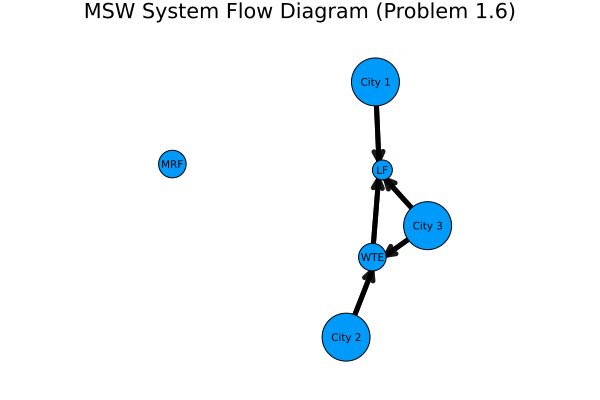

In [ ]:
using GraphRecipes
using Plots

# 1) Define node list and indices
nodes = ["City 1", "City 2", "City 3", "LF", "MRF", "WTE"]
node_index = Dict(name => i for (i, name) in enumerate(nodes))

edge_from_names = String[]
edge_to_names   = String[]
weights         = Float64[]

# City → Facility flows
for i in cities
    for f in facilities
        flow = value(x[i,f])
        if flow > 1e-6   # only show non-trivial flows
            push!(edge_from_names, "City $i")
            push!(edge_to_names,  String(f))
            push!(weights, flow)
        end
    end
end

# MRF residuals
flow_MRF_LF  = value(z_MRF_LF)
flow_MRF_WTE = value(z_MRF_WTE)

if flow_MRF_LF > 1e-6
    push!(edge_from_names, "MRF")
    push!(edge_to_names,   "LF")
    push!(weights,         flow_MRF_LF)
end

if flow_MRF_WTE > 1e-6
    push!(edge_from_names, "MRF")
    push!(edge_to_names,   "WTE")
    push!(weights,         flow_MRF_WTE)
end

# WTE ash → LF
flow_ash = value(a_WTE_ash)
if flow_ash > 1e-6
    push!(edge_from_names, "WTE")
    push!(edge_to_names,   "LF")
    push!(weights,         flow_ash)
end

# 2) Convert names → integer indices
src_idx = [node_index[s] for s in edge_from_names]
dst_idx = [node_index[t] for t in edge_to_names]

# 3) Normalize line widths so big flows look thicker
maxw = maximum(weights)
linew = 5 .* (weights ./ maxw)  # max linewidth = 5

# 4) Node sizes (must be a vector)
node_sizes = fill(10.0, length(nodes))

# 5) Plot graph
graphplot(
    src_idx,
    dst_idx;
    names = nodes,
    curves = false,
    arrowsize = 0.8,
    linewidth = linew,
    linealpha = 0.9,
    nodeshape = :circle,
    node_weights = node_sizes,
    title = "MSW System Flow Diagram (Problem 1.6)"
)



Nodes represent the three cities and the three facilities (LF, MRF, WTE).

Arrows show where waste or ash flows:

- City → LF/MRF/WTE for MSW shipments

- MRF → LF/WTE for residuals

- WTE → LF for ash

Arrow thickness is proportional to the amount of flow on that link, so thicker arrows indicate higher tonnage.

The diagram visually summarizes the optimal solution by showing:

- Which facilities are actually used

- How each city’s waste is routed

- How much material passes through the MRF/WTE before final landfill disposal.

### Problem 2 (6 points)

Consider a two-period economic dispatch problem, based on the
multi-period example from Lecture 14 (on 10/29). The generator data,
including ramping constraints for each generator, is provided in
\`data/generators.csv.’ In period 1, the demand is
$d_1 = 1100 \text{MW}$. In period 2, the demand is projected to be
$d_2 = 1200 \text{MW}$, but there is a 25% probability that it is \$1500
. In the first period, the solar capacity factor is $0.9$ and the wind
capacity factor is $0.45$, but in the second period, there is some
uncertainty: the forecasted solar and wind capacity factors are $0.95$
and $0.4$, respectively, but there is a 30% probability that they are
$0.75$ and $0.5$. Your goal is to identify how to dispatch your
generators to minimize the cost of meeting demand.

#### Problem 2.1

Draw a scenario tree for this problem.

In [21]:


tree_str = """
Period 1                         Period 2
(No uncertainty)                 (4 scenarios)

                 d₁ = 1100
                 Sol₁ = 0.90
                 Wind₁ = 0.45

                                           ┌─ S1: D₂ = 1200, Sol₂ = 0.95, W₂ = 0.40 (p = 0.525)
                                           │
                 (root node)  ─────────────┼─ S2: D₂ = 1500, Sol₂ = 0.95, W₂ = 0.40 (p = 0.175)
                                           │
                                           ├─ S3: D₂ = 1200, Sol₂ = 0.75, W₂ = 0.50 (p = 0.225)
                                           │
                                           └─ S4: D₂ = 1500, Sol₂ = 0.75, W₂ = 0.50 (p = 0.075)
"""

println(tree_str)


Period 1                         Period 2
(No uncertainty)                 (4 scenarios)

                 d₁ = 1100
                 Sol₁ = 0.90
                 Wind₁ = 0.45

                                           ┌─ S1: D₂ = 1200, Sol₂ = 0.95, W₂ = 0.40 (p = 0.525)
                                           │
                 (root node)  ─────────────┼─ S2: D₂ = 1500, Sol₂ = 0.95, W₂ = 0.40 (p = 0.175)
                                           │
                                           ├─ S3: D₂ = 1200, Sol₂ = 0.75, W₂ = 0.50 (p = 0.225)
                                           │
                                           └─ S4: D₂ = 1500, Sol₂ = 0.75, W₂ = 0.50 (p = 0.075)



The root node (Period 1) has fixed values: 
𝑑1=1100, solar CF =0.90, wind CF =0.45.

It branches into 4 scenarios in Period 2, each with:

- a demand level 𝐷2,
- solar and wind capacity factors,
- and a probability 
𝑝(products of the demand and CF probabilities).

This visually represents the two-stage structure: one deterministic first stage and four possible second-stage outcomes.

#### Problem 2.2

Formulate a stochastic linear program for this problem based on your
scenario tree from Problem 2.1 and the data in `data/generators.csv`.

In [29]:
using JuMP, HiGHS
using CSV, DataFrames

# 1. Read generator data
gens = CSV.read("data/generators.csv", DataFrame)

println("Columns in generators.csv: ", names(gens))

G = 1:nrow(gens)   # generator index set

# Classifying generators based on Resource column
thermal = Int[]
solar   = Int[]
wind    = Int[]

for g in G
    r = lowercase(String(gens.Resource[g]))
    if occursin("solar", r)
        push!(solar, g)
    elseif occursin("wind", r)
        push!(wind, g)
    else
        push!(thermal, g)
    end
end

println("Thermal gens: ", thermal)
println("Solar gens:   ", solar)
println("Wind gens:    ", wind)

# Using VarCost as cost, and Ramp as both RU and RD
# So:
#  cost[g] = gens.VarCost[g]
#  RU[g]   = gens.Ramp[g]
#  RD[g]   = gens.Ramp[g]

# 2. Scenario data (from 2.1)
Ω = 1:4   # scenario index set

# Period 1 demand
d1 = 1100.0   # MW

# Period 2 demands per scenario
d2 = Dict(
    1 => 1200.0,
    2 => 1200.0,
    3 => 1500.0,
    4 => 1500.0
)

# Scenario probabilities
p = Dict(
    1 => 0.525,
    2 => 0.225,
    3 => 0.175,
    4 => 0.075
)

# Capacity factors for period 1 (deterministic)
CF1 = Dict{Int,Float64}()
for g in solar
    CF1[g] = 0.90
end
for g in wind
    CF1[g] = 0.45
end

# Capacity factors for period 2 by scenario
# Scenarios 1 & 3: Sol=0.95, Wind=0.40
# Scenarios 2 & 4: Sol=0.75, Wind=0.50
CF2 = Dict{Tuple{Int,Int},Float64}()
for ω in Ω
    for g in solar
        CF2[(g,ω)] = (ω == 1 || ω == 3) ? 0.95 : 0.75
    end
    for g in wind
        CF2[(g,ω)] = (ω == 1 || ω == 3) ? 0.40 : 0.50
    end
end

# 3. Build stochastic LP
model2 = Model(HiGHS.Optimizer)

# First-stage (period 1) generator outputs
@variable(model2, P1[g in G] >= 0)

# Second-stage (period 2) outputs per scenario
@variable(model2, P2[g in G, ω in Ω] >= 0)

# 4. Objective: expected total cost
@objective(model2, Min,
    # Period 1 cost
    sum(gens.VarCost[g] * P1[g] for g in G)
    +
    # Expected period 2 cost
    sum( p[ω] * sum(gens.VarCost[g] * P2[g,ω] for g in G) for ω in Ω )
)

# 5. Constraints
# (a) Period 1 demand balance
@constraint(model2,
    sum(P1[g] for g in G) == d1
)

# (b) Period 1 capacity & CF constraints
for g in G
    if g in thermal
        @constraint(model2, gens.Pmin[g] <= P1[g] <= gens.Pmax[g])
    elseif g in solar || g in wind
        # CF1[g] is only defined for solar/wind
        @constraint(model2, 0 <= P1[g] <= CF1[g] * gens.Pmax[g])
    end
end

# (c) Period 2 constraints for each scenario
for ω in Ω
    # Demand balance in period 2
    @constraint(model2,
        sum(P2[g,ω] for g in G) == d2[ω]
    )

    for g in G
        # Capacity / CF limits in period 2
        if g in thermal
            @constraint(model2, gens.Pmin[g] <= P2[g,ω] <= gens.Pmax[g])
        elseif g in solar || g in wind
            @constraint(model2, 0 <= P2[g,ω] <= CF2[(g,ω)] * gens.Pmax[g])
        end

        # Ramping constraints between period 1 and 2 (use Ramp for both RU and RD)
        @constraint(model2, P2[g,ω] - P1[g] <= gens.Ramp[g])  # ramp-up
        @constraint(model2, P1[g] - P2[g,ω] <= gens.Ramp[g])  # ramp-down
    end
end

# 6. Solve 
optimize!(model2)
println("Termination status: ", termination_status(model2))
println("Optimal expected cost = ", objective_value(model2))


Columns in generators.csv: ["Plant", "Resource", "Pmin", "Pmax", "VarCost", "Ramp", "Column7"]


┌ Warning: thread = 1 warning: parsed expected 6 columns, but didn't reach end of line around data row: 3. Parsing extra columns and widening final columnset
└ @ CSV /Users/techexpress/.julia/packages/CSV/XLcqT/src/file.jl:593
┌ Warning: thread = 1 warning: only found 6 / 7 columns around data row: 4. Filling remaining columns with `missing`
└ @ CSV /Users/techexpress/.julia/packages/CSV/XLcqT/src/file.jl:592
┌ Warning: thread = 1 warning: only found 6 / 7 columns around data row: 5. Filling remaining columns with `missing`
└ @ CSV /Users/techexpress/.julia/packages/CSV/XLcqT/src/file.jl:592
┌ Warning: thread = 1 warning: only found 6 / 7 columns around data row: 6. Filling remaining columns with `missing`
└ @ CSV /Users/techexpress/.julia/packages/CSV/XLcqT/src/file.jl:592


Thermal gens: [1, 2, 3, 4, 5]
Solar gens:   [7]
Wind gens:    [6]
Running HiGHS 1.12.0 (git hash: 755a8e027a): Copyright (c) 2025 HiGHS under MIT licence terms
LP has 96 rows; 35 cols; 182 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [4e-01, 4e+02]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 2e+03]
Presolving model
61 rows, 30 cols, 126 nonzeros  0s
9 rows, 20 cols, 28 nonzeros  0s
Dependent equations search running on 2 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
6 rows, 11 cols, 16 nonzeros  0s
Presolve reductions: rows 6(-90); columns 11(-24); nonzeros 16(-166) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     1.7720235315e+04 Pr: 2(1240) 0s
          2     1.7926750000e+04 Pr: 0(0) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simple


{Model structure.}
In the first stage, choose generation levels for period~1 before uncertainty is realized.
In the second stage, choose scenario--dependent period~2 dispatch values after one of the four scenarios from the scenario tree is observed.

{Decision variables.}
Define
$P_{g,1}$ (MW): period~1 output of generator $g$, and
$P_{g,2}^{\omega}$ (MW): period~2 output of generator $g$ in scenario $\omega$.
The first stage variables are identical across all scenarios, while the second stage variables adapt to the realized scenario.

{Objective function.}
The objective minimizes the sum of period~1 cost and the expected period~2 cost:
\begin{equation}
\min \left( \sum_{g} c_g P_{g,1} \right)
\;+\;
\sum_{\omega} p_{\omega} \left( \sum_{g} c_g P_{g,2}^{\omega} \right),
\end{equation}
where $c_g$ are variable generation costs and $p_{\omega}$ are the scenario probabilities from Problem~2.1.

{Period 1 constraints.}
Demand in period~1 must be satisfied:
\begin{equation}
\sum_{g} P_{g,1} = d_1.
\end{equation}
Thermal generators must satisfy minimum and maximum power limits,
and solar/wind generators are limited by their period~1 capacity factors.

{Period 2 constraints.}
For each scenario $\omega$,
\begin{equation}
\sum_{g} P_{g,2}^{\omega} = d_2^{\omega},
\end{equation}
so demand is exactly met in all scenarios.
Thermal generators again satisfy min-max limits, while renewable generators are constrained by their scenario. specific capacity factors from the scenario tree.
Ramping limits couple the two stages:
\begin{equation}
P_{g,2}^{\omega} - P_{g,1} \le RU_g, 
\qquad 
P_{g,1} - P_{g,2}^{\omega} \le RD_g.
\end{equation}

{Interpretation.}
The first stage dispatch $P_{g,1}$ is chosen to hedge against all four possible period~2 outcomes,
while the recourse variables $P_{g,2}^{\omega}$ allow the system to adjust economically and feasibly to the realized demand and renewable availability.
Together, these constraints produce a valid deterministic equivalent representation of the two stage stochastic dispatch problem.


## References

List any external references consulted, including classmates.